# temporal predictions 

Minimal notebook setup for exploring predictive coding with NumPy, PyTorch, and torchvision.

In [253]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.nn.functional as F
import math
import os as os

In [254]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")

Using device: cpu
PyTorch: 2.13.0
NumPy: 2.5.2


dataset/input variables

In [255]:
if not os.path.exists("./data/MovingMNIST/mnist_test_seq.npy"):
    datasets.MovingMNIST._URL = "https://huggingface.co/datasets/goodgoodideas/STDN/resolve/main/mnist_test_seq.npy"
input_data = datasets.MovingMNIST(root="./data", split=None, download=True)

In [256]:
def make_variables(image, initial_r_size=64, num_channels=16, num_layers=2, kernel_size=4, padding=1, stride=2):
    I = image
    if I.ndim == 4:
        previous_num_channels = I.shape[1]
    elif I.ndim == 3:
        previous_num_channels = I.shape[0]
    else:
        previous_num_channels = 1
    r = []
    deconvs = []
    out_channels = num_channels * 2
    for i in range(num_layers):
        r_size = initial_r_size // (2 ** (i + 1))
        r.append(torch.randn(1, out_channels, r_size, r_size) * 0.01)
        deconvs.append(nn.ConvTranspose2d(out_channels, previous_num_channels, kernel_size=kernel_size, padding=padding, stride=stride, bias=False))
        previous_num_channels = out_channels
        out_channels = out_channels * 2
    return I, r, deconvs

spatial pretrain


In [257]:
def pretrain_spatial(frames, r_init, alpha, lambda_u, lr_r, lr_u, sigma_2, num_epochs, num_epochs_inner, num_layers, deconvs):
    print("Starting Spatial Pre-training...")
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    for epoch in range(num_epochs):
        for I in frames:
            I_curr = I.float()
            if I_curr.ndim == 3:
                I_curr = I_curr.unsqueeze(0)
            I_curr = I_curr - I_curr.mean()

            r_curr = [ri.clone() for ri in r_init]
            e_spatial = [None] * num_layers

            for _ in range(num_epochs_inner):
                e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))
                for i in range(1, num_layers):
                    e_spatial[i] = r_curr[i - 1] - f(deconvs[i](r_curr[i]))

                for i in range(num_layers):
                    cauchy_prior = alpha * (2 * r_curr[i] / (1 + r_curr[i] ** 2))
                    bottom_up = F.conv2d(e_spatial[i], deconvs[i].weight, padding=deconvs[i].padding, stride=deconvs[i].stride)
                    dr = (1.0 / sigma_2) * bottom_up - cauchy_prior
                    if i < num_layers - 1:
                        dr = dr - (1.0 / sigma_2) * e_spatial[i + 1]
                    r_curr[i] = (r_curr[i] + lr_r * dr).detach()
                    r_curr[i].requires_grad = True

            for j in range(num_layers):
                if j > 0:
                    e_spatial[j] = r_curr[j - 1] - f(deconvs[j](r_curr[j]))
                else:
                    e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))

                loss = (1.0 / (2 * sigma_2)) * torch.sum(e_spatial[j]**2)
                deconvs[j].zero_grad()
                loss.backward()

                with torch.no_grad():
                    if deconvs[j].weight.grad is not None:
                        deconvs[j].weight -= lr_u * (deconvs[j].weight.grad + lambda_u * deconvs[j].weight)
                        deconvs[j].weight /= (torch.linalg.vector_norm(deconvs[j].weight, ord=2, dim=(1, 2, 3), keepdim=True) + 1e-8)
                        deconvs[j].weight.grad = None

        I_vis = frames[0].float()
        if I_vis.ndim == 3:
            I_vis = I_vis.unsqueeze(0)
        I_vis = I_vis - I_vis.mean()
        r_vis = [ri.clone() for ri in r_init]
        e_spatial = [None] * num_layers
        for _ in range(num_epochs_inner):
            e_spatial[0] = I_vis - f(deconvs[0](r_vis[0]))
            for i in range(1, num_layers):
                e_spatial[i] = r_vis[i - 1] - f(deconvs[i](r_vis[i]))
            for i in range(num_layers):
                cauchy_prior = alpha * (2 * r_vis[i] / (1 + r_vis[i] ** 2))
                bottom_up = F.conv2d(e_spatial[i], deconvs[i].weight, padding=deconvs[i].padding, stride=deconvs[i].stride)
                dr = (1.0 / sigma_2) * bottom_up - cauchy_prior
                if i < num_layers - 1:
                    dr = dr - (1.0 / sigma_2) * e_spatial[i + 1]
                r_vis[i] = (r_vis[i] + lr_r * dr).detach()
        with torch.no_grad():
            I_hat = f(deconvs[0](r_vis[0]))
            mse = torch.mean((I_vis - I_hat) ** 2).item()
        print(f"[Spatial Epoch {epoch:03d}]  Recon MSE: {mse:.6f}")
        fig, axes = plt.subplots(1, 2, figsize=(6, 3))
        axes[0].imshow(I_vis.reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[0].set_title("Original")
        axes[0].axis("off")
        axes[1].imshow(I_hat.reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[1].set_title("Reconstruction")
        axes[1].axis("off")
        plt.show()

    return deconvs


temporal nn

In [258]:
class TemporalNN(nn.Module):
    def __init__(self, r):
        super().__init__()
        self.convs = nn.ModuleList()
        for ri in r:
            channels = ri.shape[1]
            conv = nn.Sequential(
                nn.Conv2d(channels * 2, channels // 2, kernel_size=3, padding=1), #bottleneck to force it to learn more general 
                nn.ReLU(),

                nn.Dropout2d(p=0.1),

                nn.Conv2d(channels // 2, channels // 2, kernel_size=3, padding=1),
                nn.ReLU(),

                nn.Conv2d(channels // 2, channels, kernel_size=3, padding=1),
            )
            nn.init.zeros_(conv[-1].weight)
            nn.init.zeros_(conv[-1].bias)
            self.convs.append(conv)

    def forward(self, r_prev2, r_prev1):
        r_hat = []
        for conv, r2, r1 in zip(self.convs, r_prev2, r_prev1):
            x = torch.cat([r2, r1], dim=1)
            delta = conv(x)
            r_hat.append(r1 + delta)
        return r_hat


Training Loop

In [259]:


def train_loop(I_curr, r_prev2, r_prev1, r_curr, alpha, lambda_u, lr_r, lr_u,sigma_2, num_epochs_outer, num_epochs_inner, num_layers, deconvs, temporal_nn):
    I_curr = I_curr.float()
    if I_curr.ndim == 3:
        I_curr = I_curr.unsqueeze(0)
    e_spatial = [None] * num_layers
    e_temporal = [None] * num_layers
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    if r_prev1 is None:
        r_prev1 = [torch.zeros_like(ri) for ri in r_curr]
    else:
        r_prev1 = [ri.detach() for ri in r_prev1]

    if r_prev2 is None:
        r_prev2 = [torch.zeros_like(ri) for ri in r_prev1]
    else:
        r_prev2 = [ri.detach() for ri in r_prev2]

    
    for out_epoch in range(num_epochs_outer):
        r_prev1 = [ri.detach() for ri in r_prev1]
        r_prev2 = [ri.detach() for ri in r_prev2]
        r_pred = temporal_nn(r_prev2, r_prev1)

        for in_epoch in range(num_epochs_inner):
            e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))

            for i in range(1, num_layers):
                e_spatial[i] = r_curr[i - 1] - f(deconvs[i](r_curr[i]))
            
            for i in range(num_layers):
                cauchy_prior = alpha * (2 * r_curr[i] / (1 + r_curr[i] ** 2))
                bottom_up = F.conv2d(e_spatial[i], deconvs[i].weight, padding=deconvs[i].padding, stride=deconvs[i].stride)
                dr = (1.0 / sigma_2) * bottom_up - cauchy_prior - (1.0 / sigma_2) * (r_curr[i] - r_pred[i])
                if i < num_layers - 1:
                    dr = dr - (1.0 / sigma_2) * e_spatial[i + 1]
                r_curr[i] = (r_curr[i] + lr_r * dr).detach()
                r_curr[i].requires_grad = True

        e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))
        r_pred = temporal_nn(r_prev2, r_prev1)
        total_loss = 0

        for j in range(num_layers):
            if j > 0:
                e_spatial[j] = r_curr[j - 1] - f(deconvs[j](r_curr[j]))
            e_temporal[j] = r_curr[j] - r_pred[j]

            total_loss += (1.0 / (2 * sigma_2)) * (torch.sum(e_spatial[j]**2) + F.smooth_l1_loss(r_curr[j], r_pred[j], reduction='sum'))

            deconvs[j].zero_grad()
        temporal_nn.zero_grad()
        
        total_loss.backward()
        
        
        
    
        with torch.no_grad():
            for j in range(num_layers):
                if deconvs[j].weight.requires_grad and deconvs[j].weight.grad is not None:
                    deconvs[j].weight -= lr_u * (deconvs[j].weight.grad + lambda_u * deconvs[j].weight)
                    deconvs[j].weight /= (torch.linalg.vector_norm(deconvs[j].weight, ord=2, dim=(1, 2, 3), keepdim=True) + 1e-8)
                    deconvs[j].weight.grad = None
            for param in temporal_nn.parameters():
                if param.grad is not None:
                    param -= lr_u * (param.grad + lambda_u * param)
                    #param /= (torch.linalg.vector_norm(param, ord=2) + 1e-8)
                    param.grad = None

    return r_curr


sequential training

In [260]:
def train_video_sequence(sequence, r_curr_init, alpha, lambda_u, lr_r, lr_u, sigma_2, num_epochs_outer, num_epochs_inner, num_layers, deconvs, temporal_nn, noise_std=0.0):
    r_prev2 = None
    r_prev1 = None
    r_curr = r_curr_init
    r_sequence = []
    
    for i, image in enumerate(sequence):
        I_curr = image.float()
        if noise_std > 0:
            I_curr = I_curr + torch.randn_like(I_curr) * noise_std

        r_curr = train_loop(
            I_curr, r_prev2, r_prev1, r_curr, 
            alpha, lambda_u, lr_r, lr_u, sigma_2, 
            num_epochs_outer, num_epochs_inner, num_layers, 
            deconvs, temporal_nn
        )

        r_sequence.append([ri.detach().clone() for ri in r_curr])
        
        r_prev2 = r_prev1
        r_prev1 = [ri.detach() for ri in r_curr]   

    return r_sequence


validation


In [261]:
def validate_heirarchical(seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn):
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    T = seq.shape[0]
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)
    e_spatial = [None] * num_layers

    r_prev2 = None
    r_prev1 = None
    r_curr = [ri.clone() for ri in r_init]

    true_frames = []
    pred_frames = []

    for t in range(T):
        I_curr = seq[t] - seq[t].mean()
        if I_curr.ndim == 3:
            I_curr = I_curr.unsqueeze(0)

        if r_prev1 is None:
            r_prev1_use = [torch.zeros_like(ri) for ri in r_curr]
            r_prev2_use = [torch.zeros_like(ri) for ri in r_curr]
        elif r_prev2 is None:
            r_prev1_use = [ri.detach() for ri in r_prev1]
            r_prev2_use = [torch.zeros_like(ri) for ri in r_curr]
        else:
            r_prev1_use = [ri.detach() for ri in r_prev1]
            r_prev2_use = [ri.detach() for ri in r_prev2]

        if t >= 2:
            with torch.no_grad():
                r_pred = temporal_nn(r_prev2_use, r_prev1_use)
                I_hat = f(deconvs[0](r_pred[0]))
                true_frames.append(I_curr.detach().clone())
                pred_frames.append(I_hat.detach().clone())

        with torch.no_grad():
            r_pred_prior = temporal_nn(r_prev2_use, r_prev1_use)
            for _ in range(num_epochs_inner):
                e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))
                for i in range(1, num_layers):
                    e_spatial[i] = r_curr[i - 1] - f(deconvs[i](r_curr[i]))
                for i in range(num_layers):
                    cauchy_prior = alpha * (2 * r_curr[i] / (1 + r_curr[i] ** 2))
                    bottom_up = F.conv2d(e_spatial[i], deconvs[i].weight, padding=deconvs[i].padding, stride=deconvs[i].stride)
                    dr = (1.0 / sigma_2) * bottom_up - cauchy_prior - (1.0 / sigma_2) * (r_curr[i] - r_pred_prior[i])
                    if i < num_layers - 1:
                        dr = dr - (1.0 / sigma_2) * e_spatial[i + 1]
                    r_curr[i] = (r_curr[i] + lr_r * dr).detach()

        r_prev2 = r_prev1
        r_prev1 = [ri.detach().clone() for ri in r_curr]

    true_frames = torch.stack(true_frames, dim=0)
    pred_frames = torch.stack(pred_frames, dim=0)
    mse = torch.mean((true_frames - pred_frames) ** 2)
    mse_per_frame = torch.mean((true_frames - pred_frames) ** 2, dim=(1, 2, 3, 4))
    return mse, mse_per_frame, true_frames, pred_frames, r_curr


In [262]:
def validate_heirarchical_long(seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn, split_point=10):
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    T = seq.shape[0]
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)
    e_spatial = [None] * num_layers

    r_prev2 = None
    r_prev1 = None
    r_curr = [ri.clone() for ri in r_init]

    true_frames = []
    pred_frames = []

    for t in range(T):
        I_curr = seq[t] - seq[t].mean()
        if I_curr.ndim == 3:
            I_curr = I_curr.unsqueeze(0)

        if r_prev1 is None:
            r_prev1_use = [torch.zeros_like(ri) for ri in r_curr]
            r_prev2_use = [torch.zeros_like(ri) for ri in r_curr]
        elif r_prev2 is None:
            r_prev1_use = [ri.detach() for ri in r_prev1]
            r_prev2_use = [torch.zeros_like(ri) for ri in r_curr]
        else:
            r_prev1_use = [ri.detach() for ri in r_prev1]
            r_prev2_use = [ri.detach() for ri in r_prev2]

        if t >= 2:
            with torch.no_grad():
                r_pred = temporal_nn(r_prev2_use, r_prev1_use)
                I_hat = f(deconvs[0](r_pred[0]))
                true_frames.append(I_curr.detach().clone())
                pred_frames.append(I_hat.detach().clone())

        if t >= split_point:
            # pred_frames only stores t>=2, so index is t-2 (== -1 right after append)
            I_curr = pred_frames[t - 2] - pred_frames[t - 2].mean()
            if I_curr.ndim == 3:
                I_curr = I_curr.unsqueeze(0)

        with torch.no_grad():
            r_pred_prior = temporal_nn(r_prev2_use, r_prev1_use)
            for _ in range(num_epochs_inner):
                e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))
                for i in range(1, num_layers):
                    e_spatial[i] = r_curr[i - 1] - f(deconvs[i](r_curr[i]))
                for i in range(num_layers):
                    cauchy_prior = alpha * (2 * r_curr[i] / (1 + r_curr[i] ** 2))
                    bottom_up = F.conv2d(e_spatial[i], deconvs[i].weight, padding=deconvs[i].padding, stride=deconvs[i].stride)
                    dr = (1.0 / sigma_2) * bottom_up - cauchy_prior - (1.0 / sigma_2) * (r_curr[i] - r_pred_prior[i])
                    if i < num_layers - 1:
                        dr = dr - (1.0 / sigma_2) * e_spatial[i + 1]
                    r_curr[i] = (r_curr[i] + lr_r * dr).detach()

        r_prev2 = r_prev1
        if t >= split_point:
            r_prev1 = [ri.detach().clone() for ri in r_pred]
        else:
            r_prev1 = [ri.detach().clone() for ri in r_curr]

    true_frames = torch.stack(true_frames, dim=0)
    pred_frames = torch.stack(pred_frames, dim=0)
    mse = torch.mean((true_frames - pred_frames) ** 2)
    mse_per_frame = torch.mean((true_frames - pred_frames) ** 2, dim=(1, 2, 3, 4))
    return mse, mse_per_frame, true_frames, pred_frames, r_curr

        

test it

In [263]:
def test(seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn):
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    T = seq.shape[0]
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)
    e_spatial = [None] * num_layers

    r_prev2 = None
    r_prev1 = None
    r_curr = [ri.clone() for ri in r_init]
    pred_frames = []

    for t in range(T):
        I_curr = seq[t] - seq[t].mean()
        if I_curr.ndim == 3:
            I_curr = I_curr.unsqueeze(0)

        if r_prev1 is None:
            r_prev1_use = [torch.zeros_like(ri) for ri in r_curr]
            r_prev2_use = [torch.zeros_like(ri) for ri in r_curr]
        elif r_prev2 is None:
            r_prev1_use = [ri.detach() for ri in r_prev1]
            r_prev2_use = [torch.zeros_like(ri) for ri in r_curr]
        else:
            r_prev1_use = [ri.detach() for ri in r_prev1]
            r_prev2_use = [ri.detach() for ri in r_prev2]

        if t >= 2:
            with torch.no_grad():
                r_pred = temporal_nn(r_prev2_use, r_prev1_use)
                I_hat = f(deconvs[0](r_pred[0]))
                pred_frames.append(I_hat.detach().clone())

        with torch.no_grad():
            r_pred_prior = temporal_nn(r_prev2_use, r_prev1_use)
            for _ in range(num_epochs_inner):
                e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))
                for i in range(1, num_layers):
                    e_spatial[i] = r_curr[i - 1] - f(deconvs[i](r_curr[i]))
                for i in range(num_layers):
                    cauchy_prior = alpha * (2 * r_curr[i] / (1 + r_curr[i] ** 2))
                    bottom_up = F.conv2d(e_spatial[i], deconvs[i].weight, padding=deconvs[i].padding, stride=deconvs[i].stride)
                    dr = (1.0 / sigma_2) * bottom_up - cauchy_prior - (1.0 / sigma_2) * (r_curr[i] - r_pred_prior[i])
                    if i < num_layers - 1:
                        dr = dr - (1.0 / sigma_2) * e_spatial[i + 1]
                    r_curr[i] = (r_curr[i] + lr_r * dr).detach()

        r_prev2 = r_prev1
        r_prev1 = [ri.detach().clone() for ri in r_curr]

    if len(pred_frames) == 0:
        return r_curr, None
    pred_frames = torch.stack(pred_frames, dim=0)
    return r_curr, pred_frames


In [264]:
def main():
    num_data = 20
    sequences = [input_data[i].float() / 255.0 for i in range(num_data)]
    num_spatial_epochs = 8
    num_pretrain_frames = 200
    num_train_epochs = 20
    alpha = 0.001
    lambda_u = 0.001
    lr_r = 0.005
    lr_U = 0.002
    sigma_2 = 1.0
    num_layers = 2
    noise_std_start = 0.0
    noise_std_end = 0.6

    num_epochs_inner = 50
    num_epochs_outer = 1
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    print("=" * 60)
    print(f"Starting Training: {num_train_epochs} Epochs | {num_data} Sequences | {num_layers} Layers")
    print(f"Hyperparameters: lr_r={lr_r}, lr_U={lr_U}, alpha={alpha}, lambda_u={lambda_u}")
    print(f"Input noise schedule: {noise_std_start} -> {noise_std_end} (linear over epochs)")
    print("=" * 60)

    _, r_init, deconvs = make_variables(sequences[0][0], num_layers=num_layers)
    temporal_nn = TemporalNN(r_init)

    all_frames = [seq[t] for seq in sequences for t in range(seq.shape[0])]
    idx = torch.randperm(len(all_frames))[:num_pretrain_frames].tolist()
    pretrain_frames = [all_frames[i] for i in idx]

    deconvs = pretrain_spatial(
        pretrain_frames, r_init, alpha, lambda_u, lr_r, lr_U, sigma_2,
        num_spatial_epochs, num_epochs_inner, num_layers, deconvs
    )

    for deconv in deconvs:
        deconv.weight.requires_grad = False

    for epoch in range(num_train_epochs):
        noise_std = noise_std_start + (noise_std_end - noise_std_start) * (epoch / max(num_train_epochs - 1, 1))
        for seq in sequences:
            r_curr = [ri.clone() for ri in r_init]
            seq_centered = torch.stack([seq[t] - seq[t].mean() for t in range(seq.shape[0])], dim=0)
            train_video_sequence(
                seq_centered, r_curr, alpha, lambda_u, lr_r, lr_U, sigma_2,
                num_epochs_outer, num_epochs_inner, num_layers, deconvs, temporal_nn,
                noise_std=noise_std,
            )

        if epoch % 5 == 0 or epoch == num_train_epochs - 1:
            mse, mse_per_frame, true_frames, pred_frames, _ = validate_heirarchical(
                sequences[0], r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn
            )
            print(f"[Epoch {epoch:03d}/{num_train_epochs:03d}]  noise_std={noise_std:.4f}  Next-frame MSE: {mse:.6f}  |  Per-frame: {[f'{x:.4f}' for x in mse_per_frame.tolist()]}")

            n_show = true_frames.shape[0]
            fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3))
            for t in range(n_show):
                axes[0, t].imshow(true_frames[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
                axes[0, t].set_title(f"True {t + 2}")
                axes[0, t].axis("off")
                axes[1, t].imshow(pred_frames[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
                axes[1, t].set_title(f"Pred {t + 2}")
                axes[1, t].axis("off")
            plt.show()

    val_seq = input_data[num_data].float() / 255.0
    mse, mse_per_frame, true_frames, pred_frames, _ = validate_heirarchical(
        val_seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn
    )
    print(f"Validation  ->  Next-frame MSE: {mse:.6f}  |  Per-frame: {[f'{x:.4f}' for x in mse_per_frame.tolist()]}")

    n_show = true_frames.shape[0]
    fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3))
    for t in range(n_show):
        axes[0, t].imshow(true_frames[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[0, t].set_title(f"True {t + 2}")
        axes[0, t].axis("off")
        axes[1, t].imshow(pred_frames[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[1, t].set_title(f"Pred {t + 2}")
        axes[1, t].axis("off")
    plt.show()

    temporal_nn.eval()
    mse_lr, mse_per_frame_lr, true_frames_lr, pred_frames_lr, _ = validate_heirarchical_long(
        val_seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn
    )
    print(f"Long-run  ->  MSE: {mse_lr:.6f}  |  Per-frame: {[f'{x:.4f}' for x in mse_per_frame_lr.tolist()]}")

    n_show = true_frames_lr.shape[0]
    fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3))
    for t in range(n_show):
        # pred_frames[i] is the prediction for sequence frame t=i+2
        frame_idx = t + 2
        axes[0, t].imshow(true_frames_lr[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[0, t].set_title(f"True {frame_idx}")
        axes[0, t].axis("off")
        axes[1, t].imshow(pred_frames_lr[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[1, t].set_title(f"Pred {frame_idx}")
        axes[1, t].axis("off")
    plt.show()


Starting Training: 20 Epochs | 20 Sequences | 2 Layers
Hyperparameters: lr_r=0.005, lr_U=0.002, alpha=0.001, lambda_u=0.001
Input noise schedule: 0.0 -> 0.6 (linear over epochs)
Starting Spatial Pre-training...
[Spatial Epoch 000]  Recon MSE: 0.000464


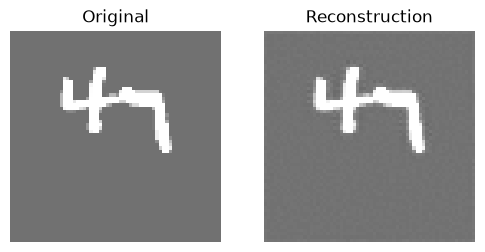

[Spatial Epoch 001]  Recon MSE: 0.000366


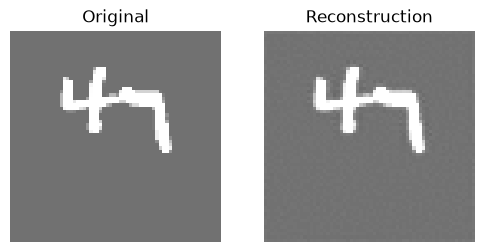

[Spatial Epoch 002]  Recon MSE: 0.000329


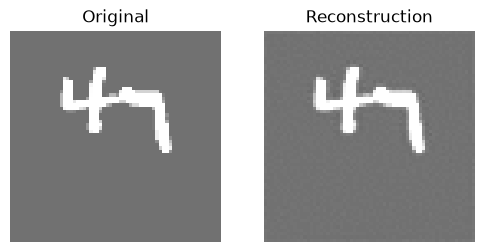

[Spatial Epoch 003]  Recon MSE: 0.000312


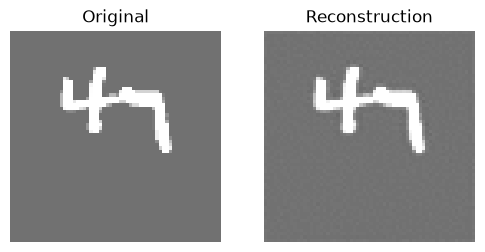

[Spatial Epoch 004]  Recon MSE: 0.000303


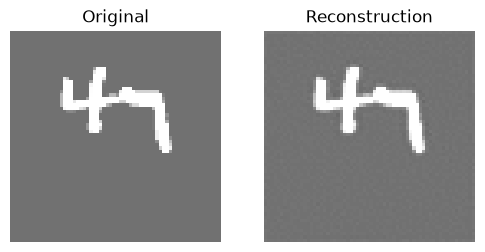

[Spatial Epoch 005]  Recon MSE: 0.000299


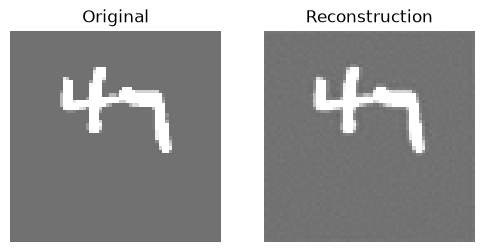

[Spatial Epoch 006]  Recon MSE: 0.000297


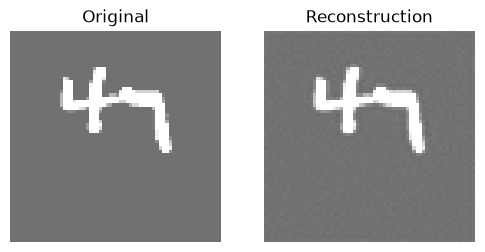

[Spatial Epoch 007]  Recon MSE: 0.000296


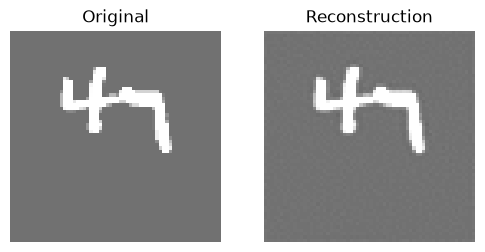

[Epoch 000/020]  noise_std=0.0000  Next-frame MSE: 0.050313  |  Per-frame: ['0.0453', '0.0443', '0.0497', '0.0443', '0.0332', '0.0588', '0.0520', '0.0582', '0.0553', '0.0513', '0.0532', '0.0514', '0.0536', '0.0534', '0.0554', '0.0577', '0.0477', '0.0410']


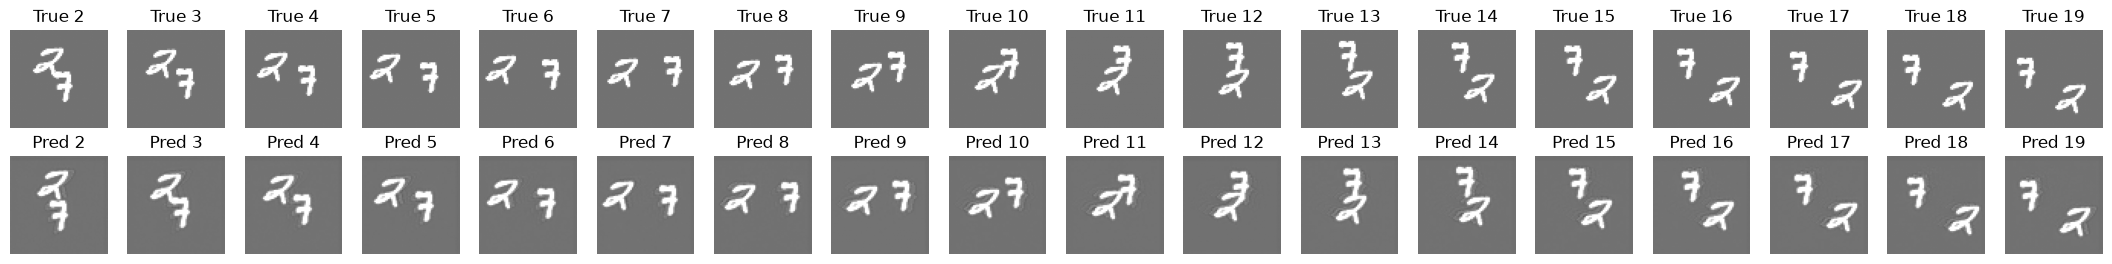

[Epoch 005/020]  noise_std=0.1579  Next-frame MSE: 0.029855  |  Per-frame: ['0.0284', '0.0281', '0.0311', '0.0288', '0.0277', '0.0291', '0.0342', '0.0296', '0.0313', '0.0263', '0.0302', '0.0306', '0.0294', '0.0290', '0.0326', '0.0319', '0.0319', '0.0273']


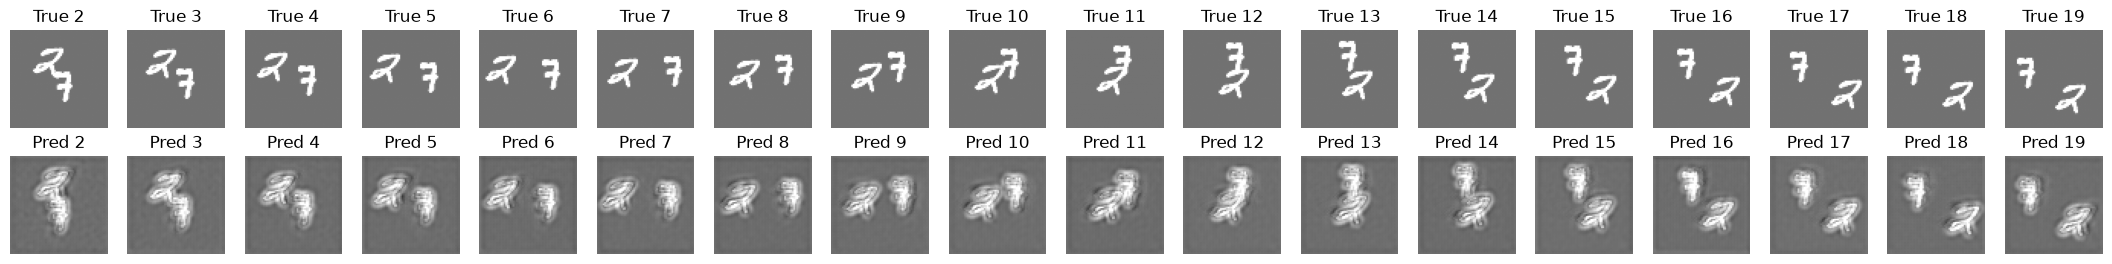

[Epoch 010/020]  noise_std=0.3158  Next-frame MSE: 0.036487  |  Per-frame: ['0.0364', '0.0352', '0.0406', '0.0353', '0.0372', '0.0369', '0.0440', '0.0413', '0.0366', '0.0306', '0.0327', '0.0348', '0.0405', '0.0350', '0.0348', '0.0340', '0.0378', '0.0330']


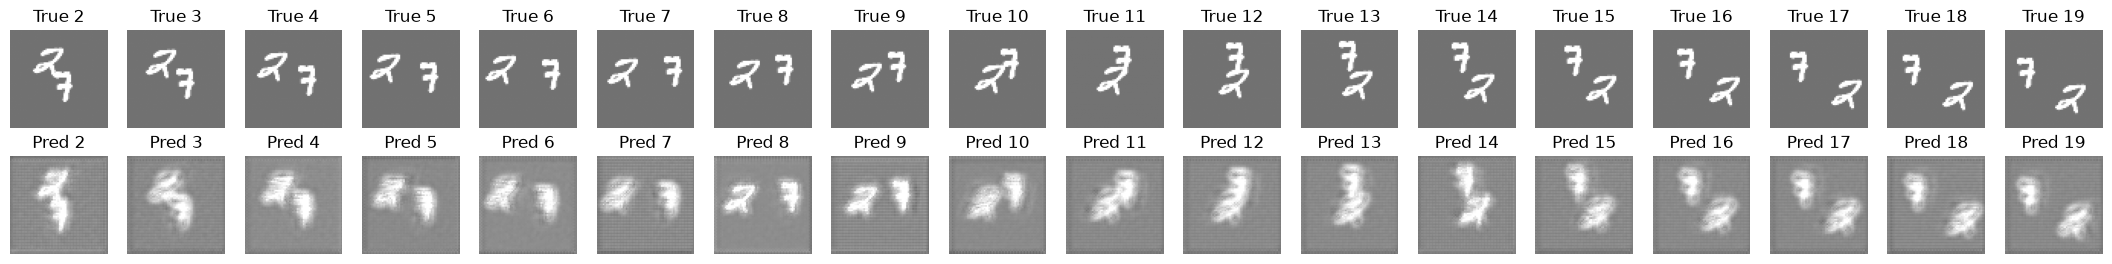

[Epoch 015/020]  noise_std=0.4737  Next-frame MSE: 0.044391  |  Per-frame: ['0.0487', '0.0445', '0.0464', '0.0425', '0.0374', '0.0468', '0.0468', '0.0429', '0.0461', '0.0421', '0.0430', '0.0434', '0.0456', '0.0447', '0.0428', '0.0429', '0.0475', '0.0449']


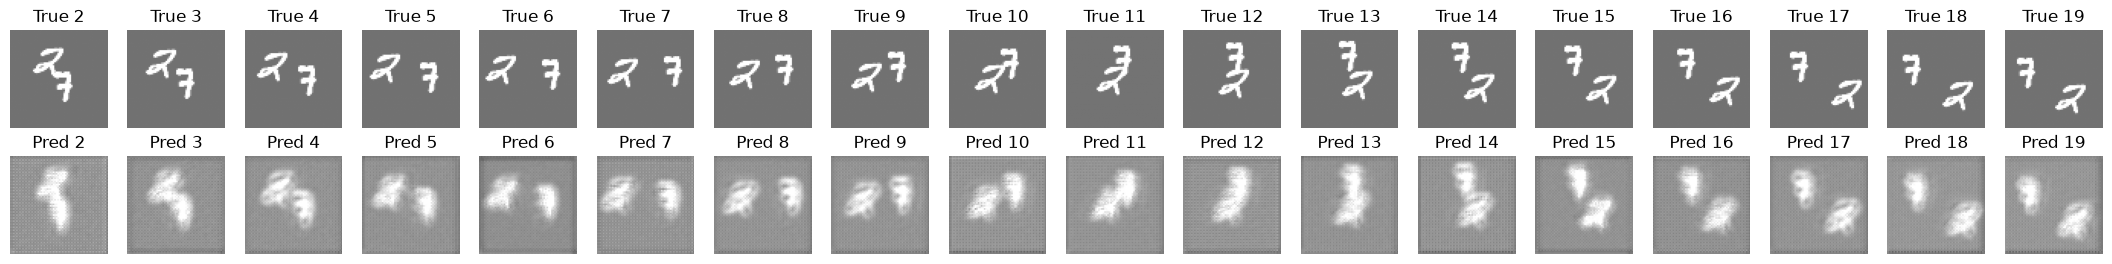

[Epoch 019/020]  noise_std=0.6000  Next-frame MSE: 0.035960  |  Per-frame: ['0.0341', '0.0362', '0.0372', '0.0359', '0.0375', '0.0364', '0.0367', '0.0350', '0.0370', '0.0309', '0.0360', '0.0384', '0.0393', '0.0367', '0.0353', '0.0340', '0.0361', '0.0345']


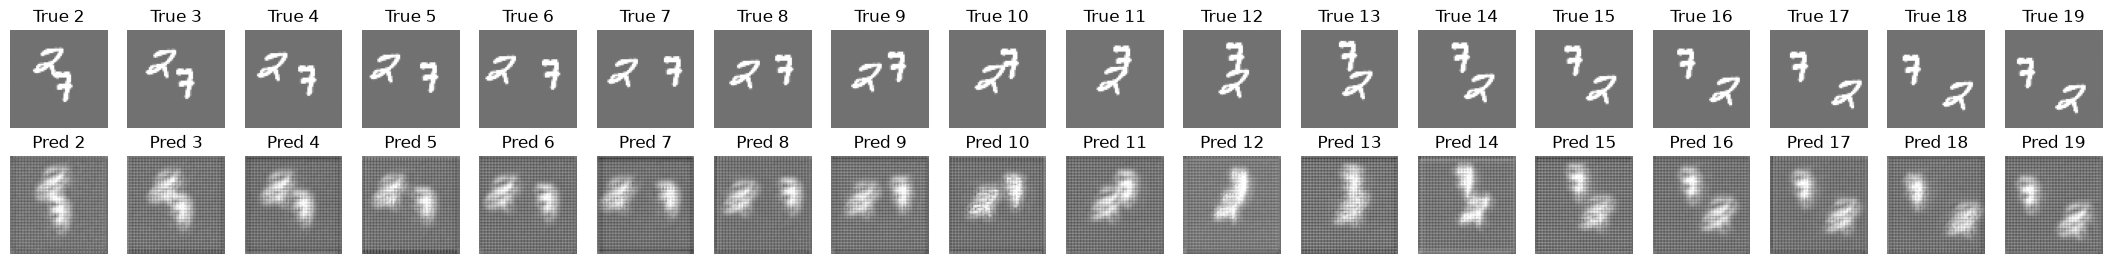

Validation  ->  Next-frame MSE: 0.033134  |  Per-frame: ['0.0301', '0.0290', '0.0332', '0.0395', '0.0312', '0.0310', '0.0336', '0.0282', '0.0319', '0.0326', '0.0342', '0.0392', '0.0420', '0.0298', '0.0289', '0.0337', '0.0327', '0.0356']


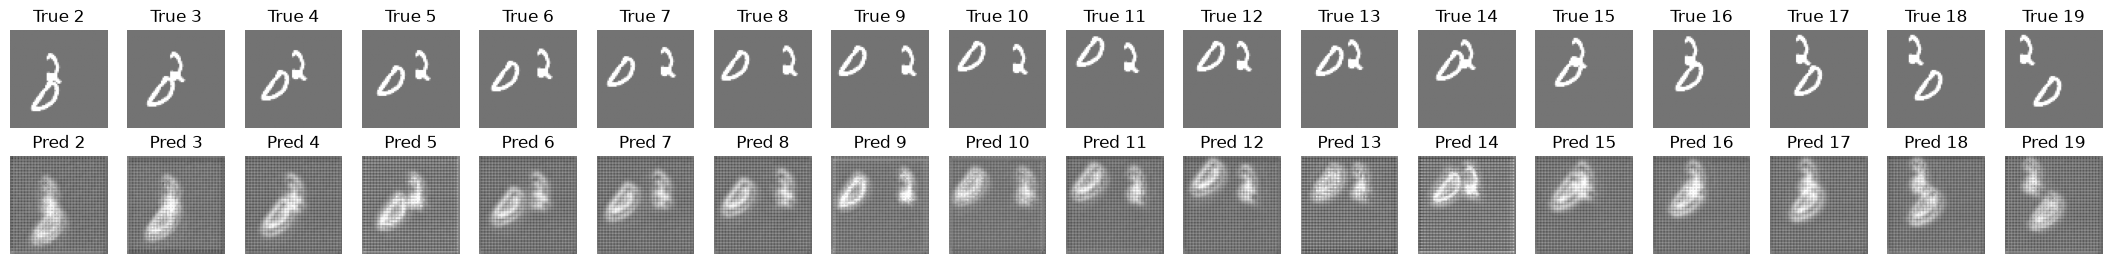

Long-run  ->  MSE: 0.067440  |  Per-frame: ['0.0295', '0.0299', '0.0341', '0.0327', '0.0322', '0.0320', '0.0343', '0.0299', '0.0338', '0.0508', '0.0637', '0.0771', '0.0883', '0.0992', '0.1147', '0.1295', '0.1433', '0.1590']


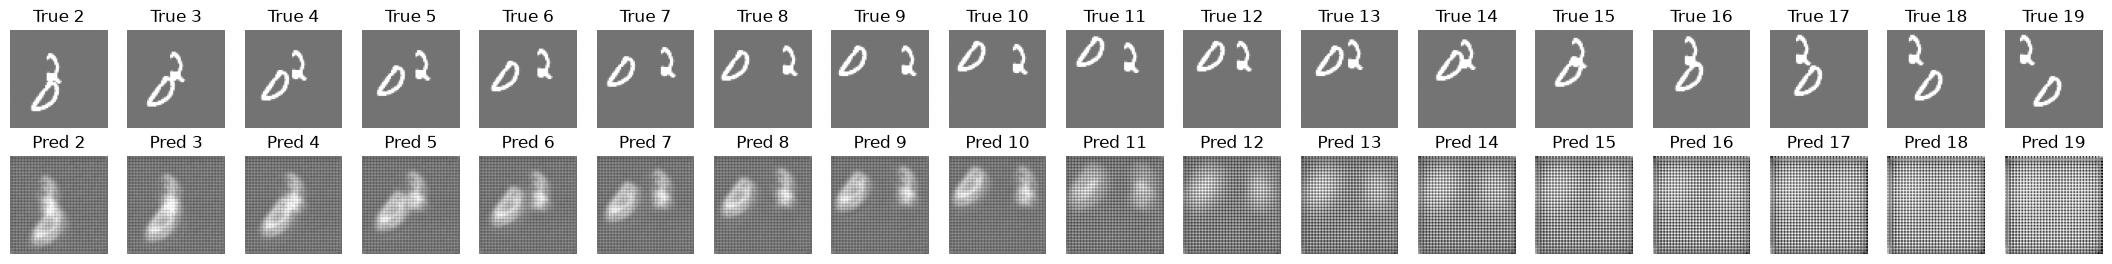

In [265]:
if __name__ == "__main__":
    main()
